# 📘 Day 4 (Afternoon) — KPI Business Dashboard
**SDNB Vaishnav College for Women, Chromepet**

**Date:** Thursday, 30 April 2026 | **Duration:** 2:00 PM – 4:00 PM

---

### 🎯 By the end of this afternoon you will:
- ✅ Build a complete **Exam Marks Analyser** with grading and ranking
- ✅ Define **business KPI functions** (margin, turnover, ROI, ATV, CAC, …)
- ✅ Calculate every KPI from real data and tag each as 🟢/🟡/🔴
- ✅ Ship a **dark-themed 3×3 dashboard** worth showing to a CEO

In [1]:
# ── Install & Setup (run this first on Google Colab) ──
import sys, os

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    print("✅ All libraries ready!")
except ImportError as e:
    print(f"Installing missing library: {e}")
    os.system("pip install pandas matplotlib numpy seaborn -q")
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

# Where the CSV data files live.
# - On Colab after uploading the workshop folder: "/content/sdnb_python_workshop/data/"
# - When running locally from notebooks/ folder:   "../data/"
DATA_PATH = "../data/" if os.path.exists("../data") else "data/"
print(f"📁 Using data path: {DATA_PATH}")

✅ All libraries ready!
📁 Using data path: ../data/


## 🔁 Recap — Day 4 Morning

This morning we used Pandas to slice CSV files. This afternoon we use those skills to build a **decision-quality dashboard**. We're now thinking like analysts, not just programmers.

## 📝 Section 1 — Exam Marks Analyser *(30 min)*

Load `exam_marks.csv` and produce:
1. Total marks, percentage, grade, rank for every student
2. Class statistics (highest, lowest, average, pass %)
3. Subject-wise analysis
4. Top-10 leaderboard + remedial list
5. Subject performance bar chart + grade distribution pie

In [2]:
import pandas as pd

marks = pd.read_csv(DATA_PATH + "exam_marks.csv")
print(f"✅ Loaded marks for {len(marks)} students")
marks.head()

✅ Loaded marks for 40 students


,RollNo,Name,Maths,Accounts,Economics,Commerce,English
0,R2026001,Aishwarya Bose,53,70,52,53,58
1,R2026002,Aishwarya Subramanian,40,47,34,34,47
2,R2026003,Saranya Subramanian,98,95,99,97,96
3,R2026004,Hemalatha Chandran,62,63,63,61,55
4,R2026005,Suresh Pillai,51,53,59,66,44


In [3]:
subjects = ["Maths", "Accounts", "Economics", "Commerce", "English"]

# Total + percentage + grade
marks["Total"]      = marks[subjects].sum(axis=1)
marks["Percentage"] = marks["Total"] / 5  # out of 100 since each subject is /100

def to_grade(p):
    if p >= 90: return "O  (Outstanding)"
    if p >= 75: return "A+ (Excellent)"
    if p >= 60: return "A  (Very Good)"
    if p >= 50: return "B+ (Good)"
    if p >= 40: return "B  (Pass)"
    return "F  (Fail)"

marks["Grade"] = marks["Percentage"].apply(to_grade)
marks["Rank"]  = marks["Percentage"].rank(method="min", ascending=False).astype(int)
marks.head()

,RollNo,Name,Maths,Accounts,Economics,Commerce,English,Total,Percentage,Grade,Rank
0,R2026001,Aishwarya Bose,53,70,52,53,58,286,57.2,B+ (Good),26
1,R2026002,Aishwarya Subramanian,40,47,34,34,47,202,40.4,B (Pass),38
2,R2026003,Saranya Subramanian,98,95,99,97,96,485,97.0,O (Outstanding),1
3,R2026004,Hemalatha Chandran,62,63,63,61,55,304,60.8,A (Very Good),23
4,R2026005,Suresh Pillai,51,53,59,66,44,273,54.6,B+ (Good),31


In [4]:
# Class statistics
n_total       = len(marks)
n_failed_any  = (marks[subjects] < 40).any(axis=1).sum()
pass_pct      = (1 - n_failed_any / n_total) * 100

class_stats = {
    "Highest %"   : f"{marks['Percentage'].max():.2f}%",
    "Lowest %"    : f"{marks['Percentage'].min():.2f}%",
    "Class Avg %" : f"{marks['Percentage'].mean():.2f}%",
    "Pass %"      : f"{pass_pct:.2f}%",
}

print("════════════════════════════════════════")
print("        CLASS PERFORMANCE SUMMARY      ")
print("════════════════════════════════════════")
for k, v in class_stats.items():
    print(f"  {k:<14s}: {v}")
print(f"  {'Total students':<14s}: {n_total}")
print(f"  {'Failed any':<14s}: {n_failed_any}")
print("════════════════════════════════════════")

════════════════════════════════════════
        CLASS PERFORMANCE SUMMARY      
════════════════════════════════════════
  Highest %     : 97.00%
  Lowest %      : 26.60%
  Class Avg %   : 65.11%
  Pass %        : 87.50%
  Total students: 40
  Failed any    : 5
════════════════════════════════════════


In [5]:
# Subject-wise analysis
subject_avg     = marks[subjects].mean().sort_values(ascending=False)
subject_pass_pct = (marks[subjects] >= 40).mean() * 100

print("\nSubject-wise averages:")
print(subject_avg.round(1).to_string())
print("\nSubject-wise pass rate:")
print(subject_pass_pct.round(1).astype(str).add(" %").to_string())

best_subject  = subject_avg.idxmax()
worst_subject = subject_pass_pct.idxmin()
print(f"\n🏆 Best subject (highest avg)     : {best_subject}")
print(f"⚠️  Subject with lowest pass rate : {worst_subject}")


Subject-wise averages:
English      67.5
Accounts     67.0
Commerce     65.9
Maths        62.7
Economics    62.6

Subject-wise pass rate:
Maths        92.5 %
Accounts     97.5 %
Economics    92.5 %
Commerce     90.0 %
English      97.5 %

🏆 Best subject (highest avg)     : English
⚠️  Subject with lowest pass rate : Commerce


In [6]:
# Top 10 leaderboard
print("\n╔════════════════════════════════════════════════╗")
print("║              TOP 10 RANKERS                    ║")
print("╠════════════════════════════════════════════════╣")
print(f"║  {'Rank':<5s}{'RollNo':<10s}{'Name':<18s}{'%':>6s}  {'Grade':<8s}  ║")
top10 = marks.sort_values("Rank").head(10)
for _, row in top10.iterrows():
    print(f"║  #{row['Rank']:<4d}{row['RollNo']:<10s}{row['Name'][:16]:<18s}{row['Percentage']:>6.1f}  {row['Grade'][:6]:<8s}  ║")
print("╚════════════════════════════════════════════════╝")

# Remedial list (failed any subject)
fail_mask = (marks[subjects] < 40).any(axis=1)
remedial  = marks[fail_mask][["RollNo","Name","Percentage","Grade"] + subjects]
print("\nRemedial list (failed at least one subject):")
print(remedial.to_string(index=False) if len(remedial) else "  None — all students passed every subject! 🎉")


╔════════════════════════════════════════════════╗
║              TOP 10 RANKERS                    ║
╠════════════════════════════════════════════════╣
║  Rank RollNo    Name                   %  Grade     ║
║  #1   R2026003  Saranya Subraman    97.0  O  (Ou    ║
║  #2   R2026026  Bharath Iyer        93.0  O  (Ou    ║
║  #3   R2026029  Mohan Natarajan     91.4  O  (Ou    ║
║  #4   R2026015  Janani Iyer         84.6  A+ (Ex    ║
║  #5   R2026013  Vignesh Nair        82.8  A+ (Ex    ║
║  #6   R2026030  Suresh Rao          81.4  A+ (Ex    ║
║  #7   R2026035  Karthik Raj         79.8  A+ (Ex    ║
║  #8   R2026025  Saranya Patel       79.4  A+ (Ex    ║
║  #9   R2026039  Kavitha Sharma      78.4  A+ (Ex    ║
║  #10  R2026024  Kavitha Murugan     77.4  A+ (Ex    ║
╚════════════════════════════════════════════════╝

Remedial list (failed at least one subject):
  RollNo                  Name  Percentage     Grade  Maths  Accounts  Economics  Commerce  English
R2026002 Aishwarya Subramanian   

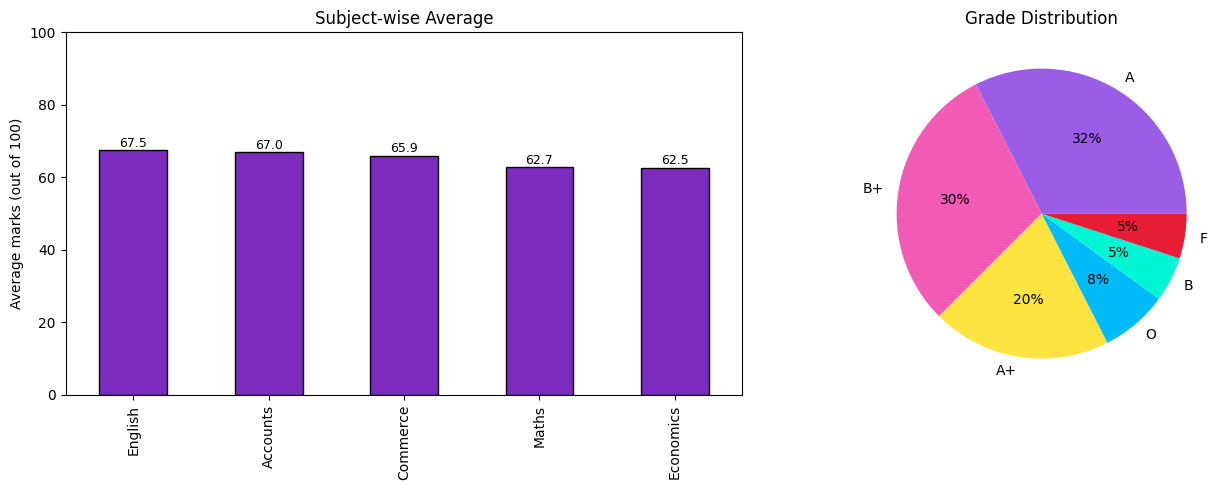

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject bar
subject_avg.plot(kind="bar", ax=axes[0], color="#7B2CBF", edgecolor="black")
axes[0].set_title("Subject-wise Average")
axes[0].set_ylabel("Average marks (out of 100)")
axes[0].set_ylim(0, 100)
for i, v in enumerate(subject_avg.values):
    axes[0].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)

# Grade distribution pie
grade_counts = marks["Grade"].apply(lambda g: g.split()[0]).value_counts()
axes[1].pie(grade_counts, labels=grade_counts.index, autopct="%1.0f%%",
            colors=["#9B5DE5", "#F15BB5", "#FEE440", "#00BBF9", "#00F5D4", "#E71D36"])
axes[1].set_title("Grade Distribution")

plt.tight_layout()
plt.show()

## 🏢 Section 2 — Business KPI Dashboard *(60 min — centrepiece)*

**Scenario:** *You have been hired as a Business Analyst intern at Chennai Fashions Pvt Ltd. The CEO wants a monthly KPI report on her desk by Monday morning. Build it in Python.*

We split this into three parts:
- **A.** KPI calculator functions (with 🟢/🟡/🔴 ratings)
- **B.** Load real data and compute every KPI
- **C.** Render a 3×3 dark-themed dashboard

### Part A — KPI Functions

Each function returns `(value, rating)`. Ratings use Indian retail rules of thumb.

**Profitability KPIs**
- Gross Profit Margin = (Revenue − COGS) / Revenue × 100
- Net Profit Margin   = Net Profit / Revenue × 100
- EBITDA Margin       = EBITDA / Revenue × 100

**Operational KPIs**
- Inventory Turnover  = COGS / Avg Inventory
- Days Sales Outstanding = (AR / Revenue) × 365
- Operating Expense Ratio = OpEx / Revenue × 100

**Growth KPIs**
- Revenue Growth (MoM) = (This − Last) / Last × 100
- Customer Acquisition Cost = Marketing / New Customers

**Retail KPIs**
- ATV  = Total Revenue / Number of Transactions
- Conversion Rate = Buyers / Visitors × 100
- ROI = (Gain − Cost) / Cost × 100

In [8]:
def _rate(value, good, ok, higher_is_better=True):
    """Compare value against thresholds and return RAG status."""
    if higher_is_better:
        if value >= good: return "🟢 Good"
        if value >= ok:   return "🟡 Avg"
        return "🔴 Watch"
    else:
        if value <= good: return "🟢 Good"
        if value <= ok:   return "🟡 Avg"
        return "🔴 Watch"


def gross_profit_margin(revenue, cogs):
    """Higher is better. Indian retail benchmark: >35% good, >25% avg."""
    v = (revenue - cogs) / revenue * 100 if revenue else 0
    return round(v, 2), _rate(v, 35, 25)

def net_profit_margin(revenue, net_profit):
    """Higher is better. Benchmark: >12% good, >6% avg."""
    v = net_profit / revenue * 100 if revenue else 0
    return round(v, 2), _rate(v, 12, 6)

def ebitda_margin(revenue, ebitda):
    """Higher is better. Benchmark: >18% good, >10% avg."""
    v = ebitda / revenue * 100 if revenue else 0
    return round(v, 2), _rate(v, 18, 10)

def inventory_turnover(cogs, avg_inventory):
    """Higher is better. Benchmark: >4x good, >2x avg."""
    v = cogs / avg_inventory if avg_inventory else 0
    return round(v, 2), _rate(v, 4, 2)

def days_sales_outstanding(ar, revenue):
    """Lower is better. Benchmark: <30d good, <60d avg."""
    v = ar / revenue * 365 if revenue else 0
    return round(v, 1), _rate(v, 30, 60, higher_is_better=False)

def operating_expense_ratio(revenue, opex):
    """Lower is better. Benchmark: <25% good, <40% avg."""
    v = opex / revenue * 100 if revenue else 0
    return round(v, 2), _rate(v, 25, 40, higher_is_better=False)

def revenue_growth(this_month, last_month):
    """Higher is better. Benchmark: >10% good, >3% avg."""
    v = (this_month - last_month) / last_month * 100 if last_month else 0
    return round(v, 2), _rate(v, 10, 3)

def customer_acquisition_cost(marketing_spend, new_customers):
    """Lower is better. Benchmark: <₹500 good, <₹1500 avg."""
    v = marketing_spend / new_customers if new_customers else 0
    return round(v, 2), _rate(v, 500, 1500, higher_is_better=False)

def average_transaction_value(revenue, transactions):
    """Higher is better. Benchmark: >₹2000 good, >₹1000 avg."""
    v = revenue / transactions if transactions else 0
    return round(v, 2), _rate(v, 2000, 1000)

def conversion_rate(buyers, visitors):
    """Higher is better. Benchmark: >35% good, >20% avg."""
    v = buyers / visitors * 100 if visitors else 0
    return round(v, 2), _rate(v, 35, 20)

def return_on_investment(gain, cost):
    """Higher is better. Benchmark: >50% good, >15% avg."""
    v = (gain - cost) / cost * 100 if cost else 0
    return round(v, 2), _rate(v, 50, 15)

### Part B — Calculate every KPI from data

In [9]:
business_data = {
    "revenue"             : 28_50_000,
    "cogs"                : 17_10_000,
    "operating_expenses"  : 5_42_000,
    "net_profit"          : 3_89_000,
    "marketing_spend"     : 1_25_000,
    "new_customers"       : 312,
    "total_transactions"  : 1840,
    "store_visitors"      : 4200,
    "accounts_receivable" : 3_45_000,
    "avg_inventory"       : 8_20_000,
    "last_month_revenue"  : 25_60_000,
}

ebitda = business_data["net_profit"] + business_data["operating_expenses"] * 0.20  # rough proxy

kpis = {
    "Gross Profit Margin"  : (gross_profit_margin(business_data["revenue"],
                                                  business_data["cogs"]),  "%"),
    "Net Profit Margin"    : (net_profit_margin(business_data["revenue"],
                                                business_data["net_profit"]), "%"),
    "EBITDA Margin"        : (ebitda_margin(business_data["revenue"], ebitda), "%"),
    "Inventory Turnover"   : (inventory_turnover(business_data["cogs"],
                                                 business_data["avg_inventory"]), "x"),
    "Days Sales Outstanding": (days_sales_outstanding(business_data["accounts_receivable"],
                                                     business_data["revenue"]), "days"),
    "OpEx Ratio"           : (operating_expense_ratio(business_data["revenue"],
                                                      business_data["operating_expenses"]), "%"),
    "Revenue Growth (MoM)" : (revenue_growth(business_data["revenue"],
                                             business_data["last_month_revenue"]), "%"),
    "CAC"                  : (customer_acquisition_cost(business_data["marketing_spend"],
                                                        business_data["new_customers"]), "₹"),
    "ATV"                  : (average_transaction_value(business_data["revenue"],
                                                        business_data["total_transactions"]), "₹"),
    "Conversion Rate"      : (conversion_rate(business_data["total_transactions"],
                                              business_data["store_visitors"]), "%"),
    "Marketing ROI"        : (return_on_investment(business_data["new_customers"] * 5000,
                                                   business_data["marketing_spend"]), "%"),
}

print("════════════════════════════════════════════════════════════")
print("       CHENNAI FASHIONS PVT LTD — KPI SCORECARD            ")
print("════════════════════════════════════════════════════════════")
for name, ((value, rating), unit) in kpis.items():
    if unit == "₹":
        v = f"₹{value:,.0f}"
    else:
        v = f"{value:,.2f}{unit}"
    print(f"  {name:<26s}: {v:>14s}   {rating}")
print("════════════════════════════════════════════════════════════")

════════════════════════════════════════════════════════════
       CHENNAI FASHIONS PVT LTD — KPI SCORECARD            
════════════════════════════════════════════════════════════
  Gross Profit Margin       :         40.00%   🟢 Good
  Net Profit Margin         :         13.65%   🟢 Good
  EBITDA Margin             :         17.45%   🟡 Avg
  Inventory Turnover        :          2.09x   🟡 Avg
  Days Sales Outstanding    :      44.20days   🟡 Avg
  OpEx Ratio                :         19.02%   🟢 Good
  Revenue Growth (MoM)      :         11.33%   🟢 Good
  CAC                       :           ₹401   🟢 Good
  ATV                       :         ₹1,549   🟡 Avg
  Conversion Rate           :         43.81%   🟢 Good
  Marketing ROI             :      1,148.00%   🟢 Good
════════════════════════════════════════════════════════════


### Part C — 3×3 Dashboard (dark theme)

C:\Users\Surya\AppData\Local\Temp\ipykernel_39084\4048048388.py:116: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Surya\AppData\Local\Temp\ipykernel_39084\4048048388.py:116: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\Surya\AppData\Local\Temp\ipykernel_39084\4048048388.py:116: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


C:\Users\Surya\AppData\Local\Temp\ipykernel_39084\4048048388.py:117: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig(CAPSTONE_DIR + "kpi_dashboard.png", dpi=150, bbox_inches="tight",
C:\Users\Surya\AppData\Local\Temp\ipykernel_39084\4048048388.py:117: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.savefig(CAPSTONE_DIR + "kpi_dashboard.png", dpi=150, bbox_inches="tight",
C:\Users\Surya\AppData\Local\Temp\ipykernel_39084\4048048388.py:117: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig(CAPSTONE_DIR + "kpi_dashboard.png", dpi=150, bbox_inches="tight",


C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


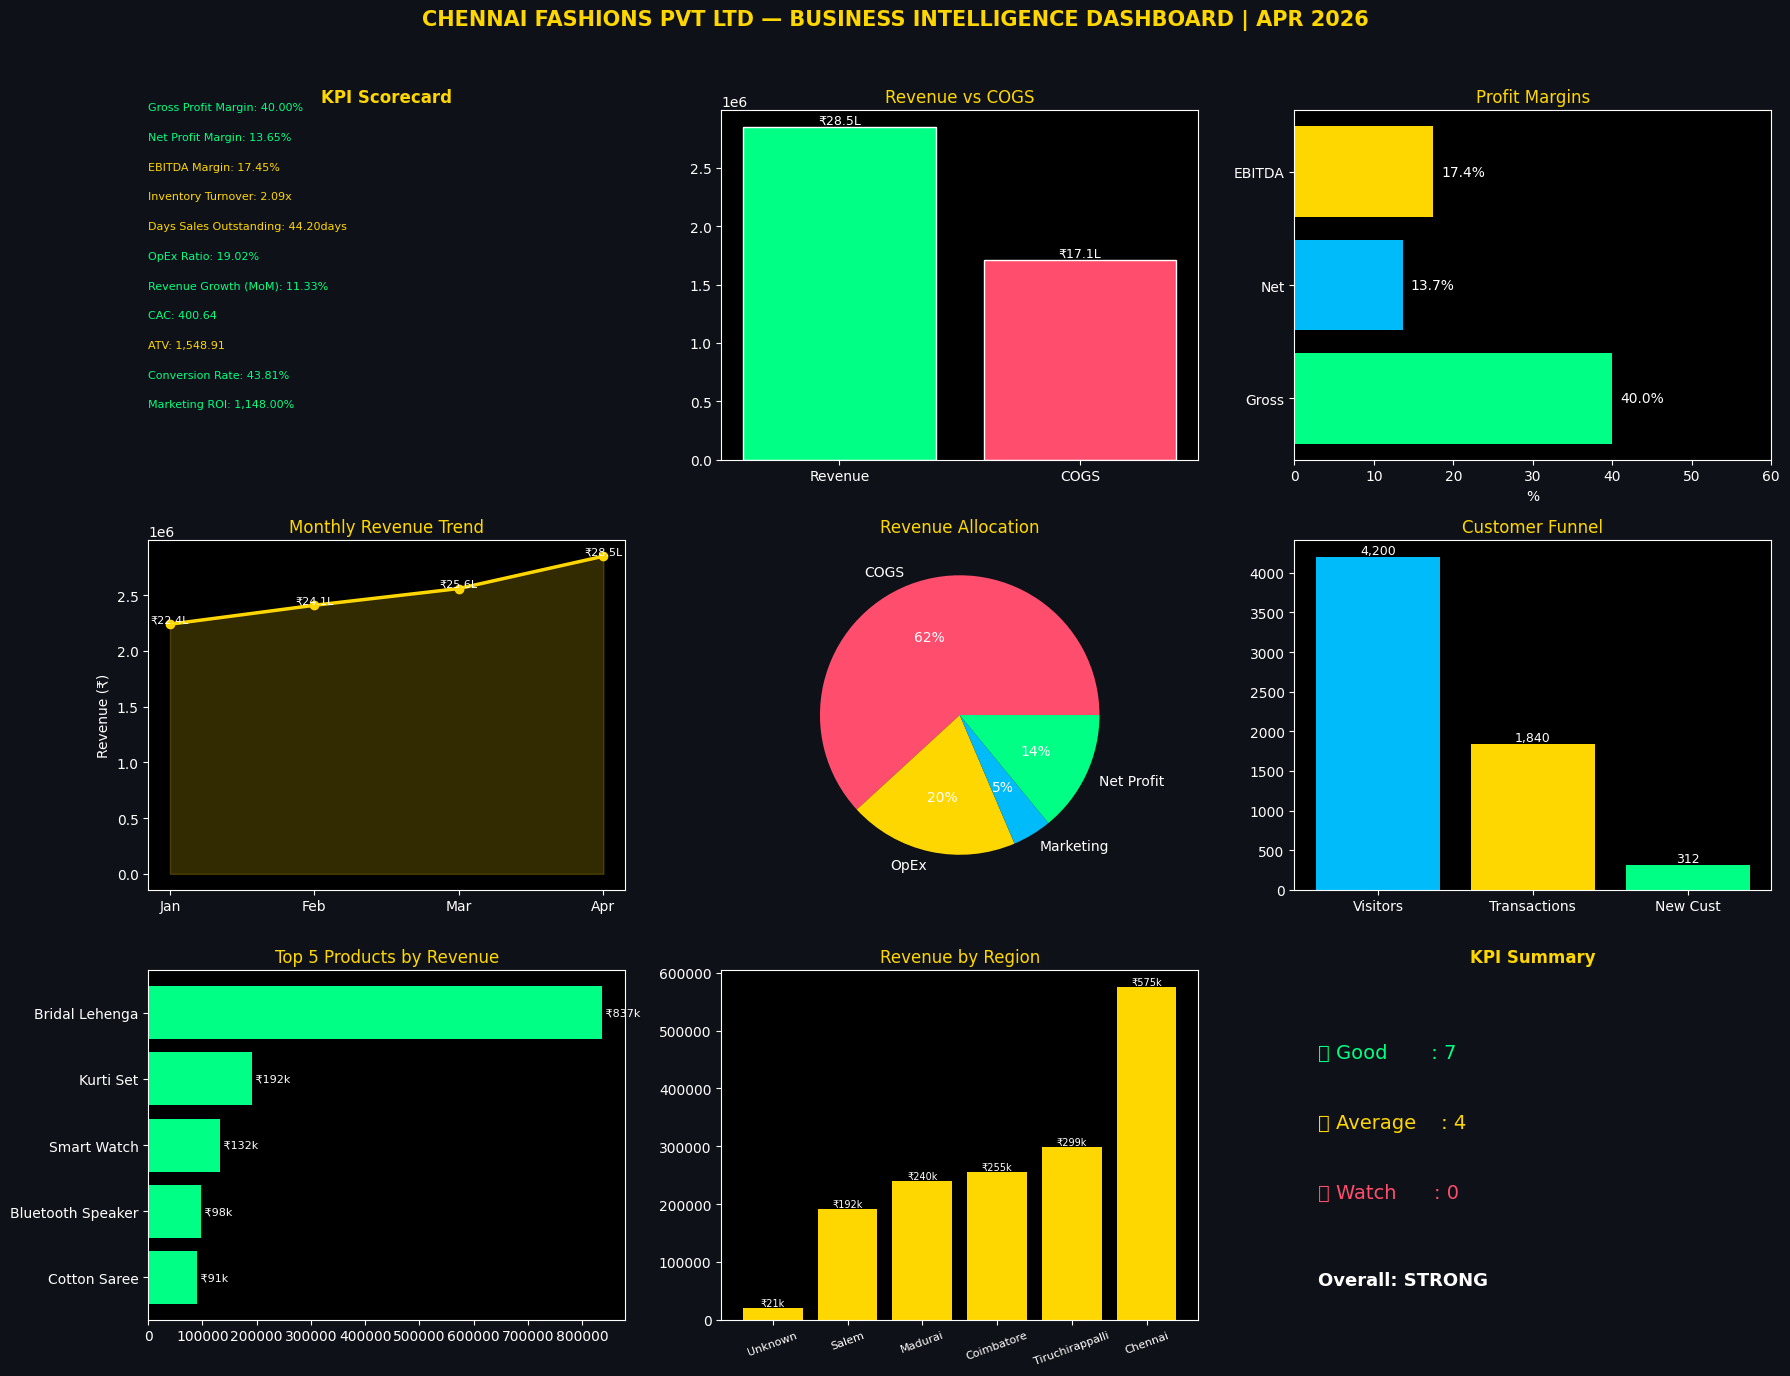

✅ Saved ../capstone/kpi_dashboard.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.style.use("dark_background")

os.makedirs("../capstone", exist_ok=True) if os.path.exists("..") else os.makedirs("capstone", exist_ok=True)
CAPSTONE_DIR = "../capstone/" if os.path.isdir("../capstone") else "capstone/"

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.patch.set_facecolor("#0e1117")
fig.suptitle("CHENNAI FASHIONS PVT LTD — BUSINESS INTELLIGENCE DASHBOARD | APR 2026",
             fontsize=15, color="#FFD700", fontweight="bold")

GOLD  = "#FFD700"
GREEN = "#00FF85"
RED   = "#FF4D6D"
BLUE  = "#00BBF9"

# Panel 1 — KPI scorecard (text)
ax = axes[0, 0]
ax.axis("off")
ax.set_title("KPI Scorecard", color=GOLD, fontweight="bold")
y = 1.0
for name, ((value, rating), unit) in kpis.items():
    color = GREEN if "🟢" in rating else (GOLD if "🟡" in rating else RED)
    text  = f"{name}: {value:,.2f}{unit if unit != '₹' else ''}"
    ax.text(0.0, y, text, color=color, fontsize=8, transform=ax.transAxes)
    y -= 0.085

# Panel 2 — Revenue vs COGS
ax = axes[0, 1]
ax.bar(["Revenue", "COGS"], [business_data["revenue"], business_data["cogs"]],
       color=[GREEN, RED], edgecolor="white")
ax.set_title("Revenue vs COGS", color=GOLD)
for i, v in enumerate([business_data["revenue"], business_data["cogs"]]):
    ax.text(i, v, f"₹{v/1e5:.1f}L", ha="center", va="bottom", color="white", fontsize=9)

# Panel 3 — Profit margins gauge bar
ax = axes[0, 2]
gp_val = kpis["Gross Profit Margin"][0][0]
np_val = kpis["Net Profit Margin"][0][0]
eb_val = kpis["EBITDA Margin"][0][0]
ax.barh(["Gross", "Net", "EBITDA"], [gp_val, np_val, eb_val],
        color=[GREEN, BLUE, GOLD])
ax.set_xlim(0, 60)
ax.set_xlabel("%")
ax.set_title("Profit Margins", color=GOLD)
for i, v in enumerate([gp_val, np_val, eb_val]):
    ax.text(v + 1, i, f"{v:.1f}%", color="white", va="center")

# Panel 4 — Monthly revenue trend (synthetic)
ax = axes[1, 0]
months   = ["Jan","Feb","Mar","Apr"]
revenues = [22_40_000, 24_10_000, business_data["last_month_revenue"], business_data["revenue"]]
ax.plot(months, revenues, marker="o", linewidth=2.5, color=GOLD)
ax.fill_between(months, revenues, alpha=0.2, color=GOLD)
for x, y in zip(months, revenues):
    ax.text(x, y, f"₹{y/1e5:.1f}L", ha="center", va="bottom", color="white", fontsize=8)
ax.set_title("Monthly Revenue Trend", color=GOLD)
ax.set_ylabel("Revenue (₹)")

# Panel 5 — Expense breakdown pie
ax = axes[1, 1]
exp_labels = ["COGS","OpEx","Marketing","Net Profit"]
exp_values = [business_data["cogs"], business_data["operating_expenses"],
              business_data["marketing_spend"], business_data["net_profit"]]
ax.pie(exp_values, labels=exp_labels, autopct="%1.0f%%",
       colors=[RED, GOLD, BLUE, GREEN], textprops={"color":"white"})
ax.set_title("Revenue Allocation", color=GOLD)

# Panel 6 — Customer metrics
ax = axes[1, 2]
metrics = ["Visitors", "Transactions", "New Cust"]
values  = [business_data["store_visitors"], business_data["total_transactions"], business_data["new_customers"]]
ax.bar(metrics, values, color=[BLUE, GOLD, GREEN])
ax.set_title("Customer Funnel", color=GOLD)
for i, v in enumerate(values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", color="white", fontsize=9)

# Panel 7 — Top products from sales_data.csv
ax = axes[2, 0]
sales = pd.read_csv(DATA_PATH + "sales_data.csv")
sales["Units"] = pd.to_numeric(sales["Units"], errors="coerce")
sales = sales.dropna(subset=["Units"])
sales["Revenue"] = sales["Units"] * sales["Price"]
top_p = sales.groupby("Product")["Revenue"].sum().sort_values(ascending=True).tail(5)
ax.barh(top_p.index, top_p.values, color=GREEN)
ax.set_title("Top 5 Products by Revenue", color=GOLD)
for i, v in enumerate(top_p.values):
    ax.text(v, i, f" ₹{v/1000:.0f}k", color="white", va="center", fontsize=8)

# Panel 8 — Regional sales
ax = axes[2, 1]
reg = sales.assign(Region=sales["Region"].fillna("Unknown")).groupby("Region")["Revenue"].sum().sort_values()
ax.bar(reg.index, reg.values, color=GOLD)
ax.set_title("Revenue by Region", color=GOLD)
ax.tick_params(axis="x", rotation=20, labelsize=8)
for i, v in enumerate(reg.values):
    ax.text(i, v, f"₹{v/1000:.0f}k", ha="center", va="bottom", color="white", fontsize=7)

# Panel 9 — KPI summary table
ax = axes[2, 2]
ax.axis("off")
ax.set_title("KPI Summary", color=GOLD, fontweight="bold")
green_n = sum(1 for (_, rt), _ in kpis.values() if "🟢" in rt)
amber_n = sum(1 for (_, rt), _ in kpis.values() if "🟡" in rt)
red_n   = sum(1 for (_, rt), _ in kpis.values() if "🔴" in rt)
ax.text(0.05, 0.75, f"🟢 Good       : {green_n}", color=GREEN, fontsize=14, transform=ax.transAxes)
ax.text(0.05, 0.55, f"🟡 Average    : {amber_n}", color=GOLD,  fontsize=14, transform=ax.transAxes)
ax.text(0.05, 0.35, f"🔴 Watch      : {red_n}",   color=RED,   fontsize=14, transform=ax.transAxes)
overall = "STRONG" if green_n >= len(kpis) // 2 else ("MIXED" if green_n + amber_n >= red_n else "ATTENTION")
ax.text(0.05, 0.10, f"Overall: {overall}", color="white", fontsize=13, fontweight="bold",
        transform=ax.transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(CAPSTONE_DIR + "kpi_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved", CAPSTONE_DIR + "kpi_dashboard.png")

### 📋 Executive Summary

In [11]:
highlights = []
concerns   = []
for name, ((value, rating), unit) in kpis.items():
    label = f"{name} = {value:,.2f}{unit if unit != '₹' else ''}"
    if "🟢" in rating:
        highlights.append(label)
    elif "🔴" in rating:
        concerns.append(label)

print("╔══════════════════════════════════════════════════════════╗")
print("║                EXECUTIVE SUMMARY (auto)                  ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  🟢 KEY HIGHLIGHTS:")
for h in highlights[:3]:
    print(f"║   • {h}")
print("║  🔴 AREAS OF CONCERN:")
for c in concerns[:2] if concerns else ["• None — all KPIs are within tolerance"]:
    print(f"║   • {c if isinstance(c, str) and c.startswith('•') else c}")
print("║  📌 RECOMMENDATION:")
if concerns:
    print(f"║   Focus on the top concern next quarter: {concerns[0]}")
else:
    print("║   Maintain current trajectory and double down on the leading category.")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║                EXECUTIVE SUMMARY (auto)                  ║
╠══════════════════════════════════════════════════════════╣
║  🟢 KEY HIGHLIGHTS:
║   • Gross Profit Margin = 40.00%
║   • Net Profit Margin = 13.65%
║   • OpEx Ratio = 19.02%
║  🔴 AREAS OF CONCERN:
║   • • None — all KPIs are within tolerance
║  📌 RECOMMENDATION:
║   Maintain current trajectory and double down on the leading category.
╚══════════════════════════════════════════════════════════╝


## 📚 Recap

- **KPI calculator functions** with rating bands (🟢/🟡/🔴)
- **Dictionary of business inputs** → calculate everything from one source
- **3×3 matplotlib dashboard** with `plt.subplots(3, 3)`
- **Dark theme styling** with `plt.style.use("dark_background")`
- **Auto-generated executive summary** — no hardcoded sentences

---

➡️ **Next: Capstone** — pulling **everything** from this week into one polished business analytics report.